Dataset Shape: (67543, 28)

First 5 Rows:
   eid       vdate rcount gender  dialysisrenalendstage  asthma  irondef  \
0    1   8/29/2012      0      F                      0       0        0   
1    2   5/26/2012     5+      F                      0       0        0   
2    3   9/22/2012      1      F                      0       0        0   
3    4    8/9/2012      0      F                      0       0        0   
4    5  12/20/2012      0      F                      0       0        0   

   pneum  substancedependence  psychologicaldisordermajor  ...     glucose  \
0      0                    0                           0  ...  192.476918   
1      0                    0                           0  ...   94.078507   
2      0                    0                           0  ...  130.530524   
3      0                    0                           0  ...  163.377028   
4      1                    0                           1  ...   94.886654   

   bloodureanitro  creatinine   

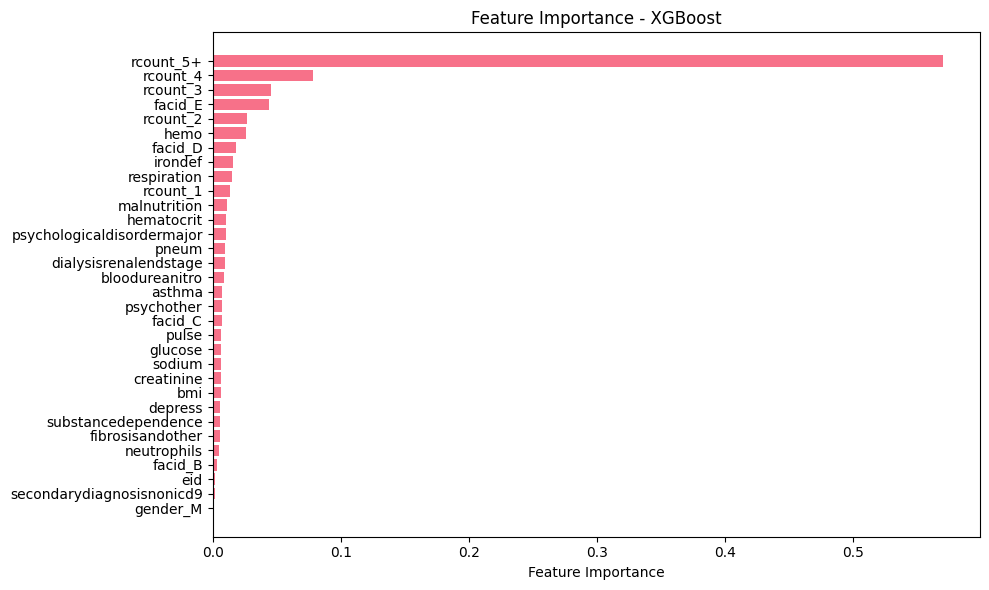

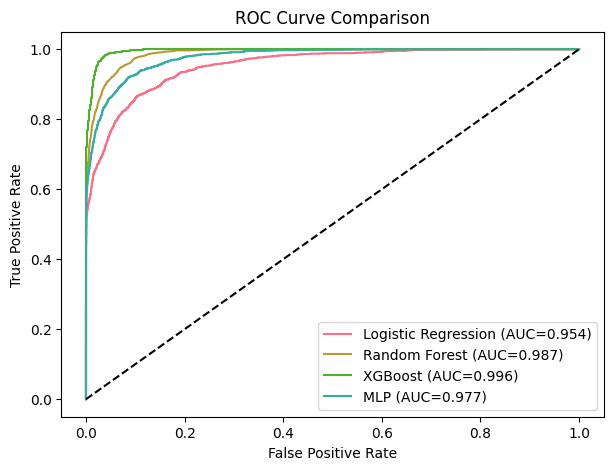

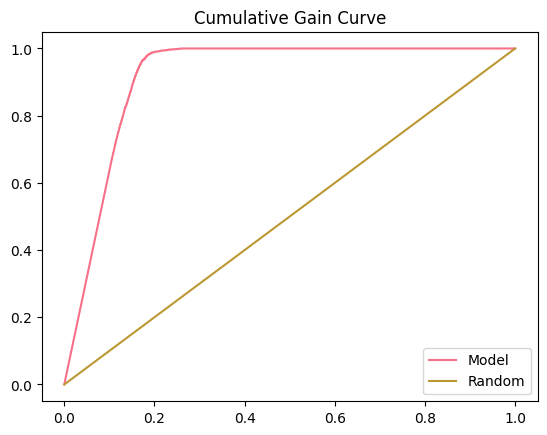

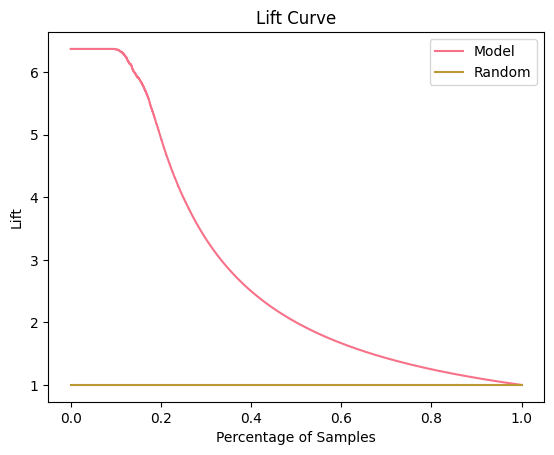

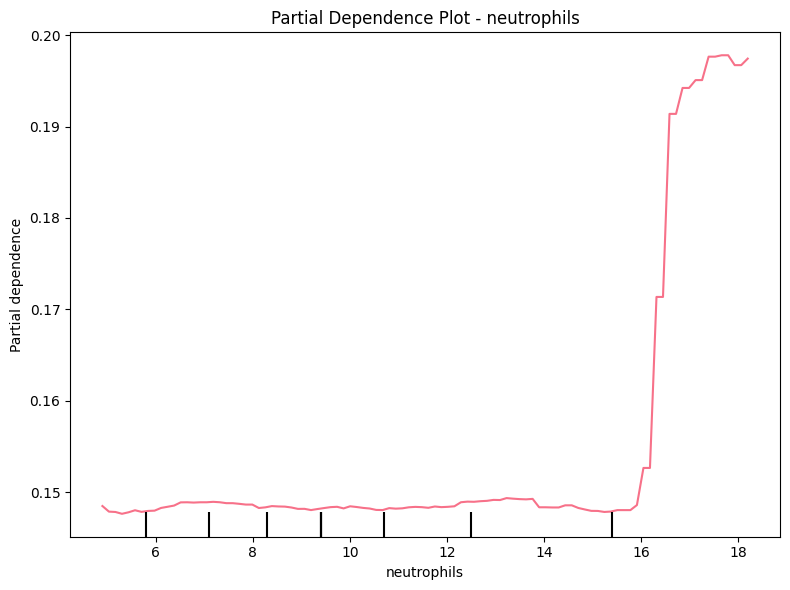

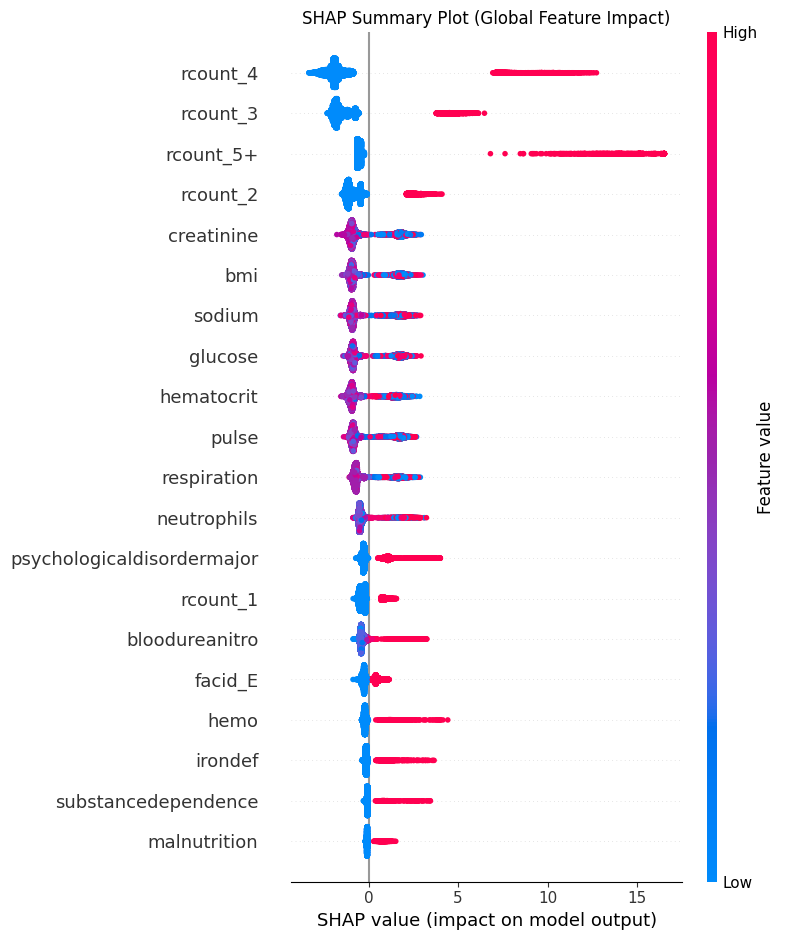

<Figure size 800x600 with 0 Axes>

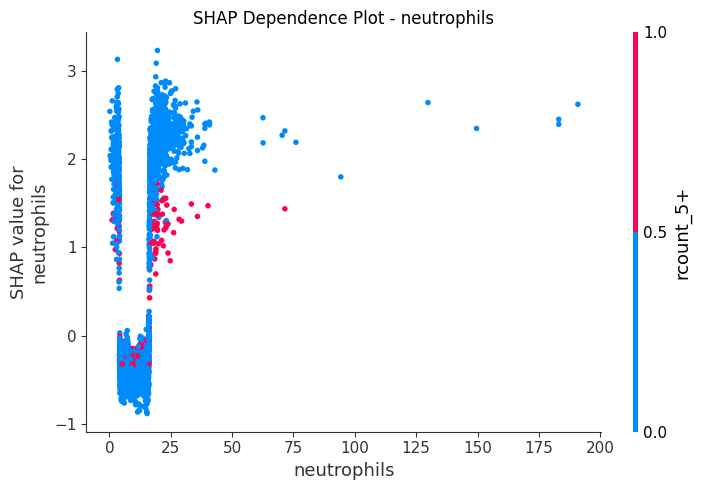

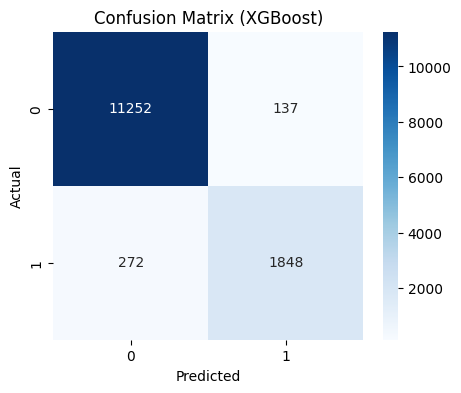

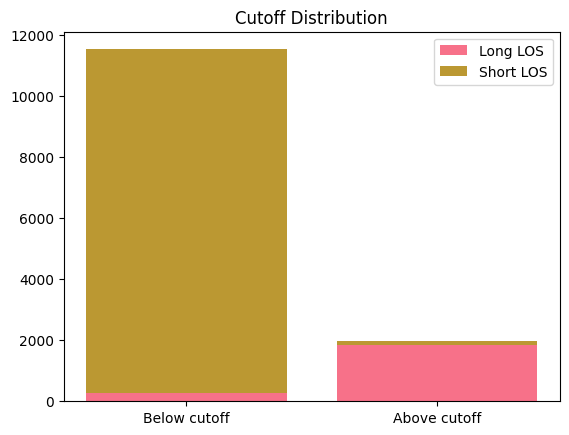

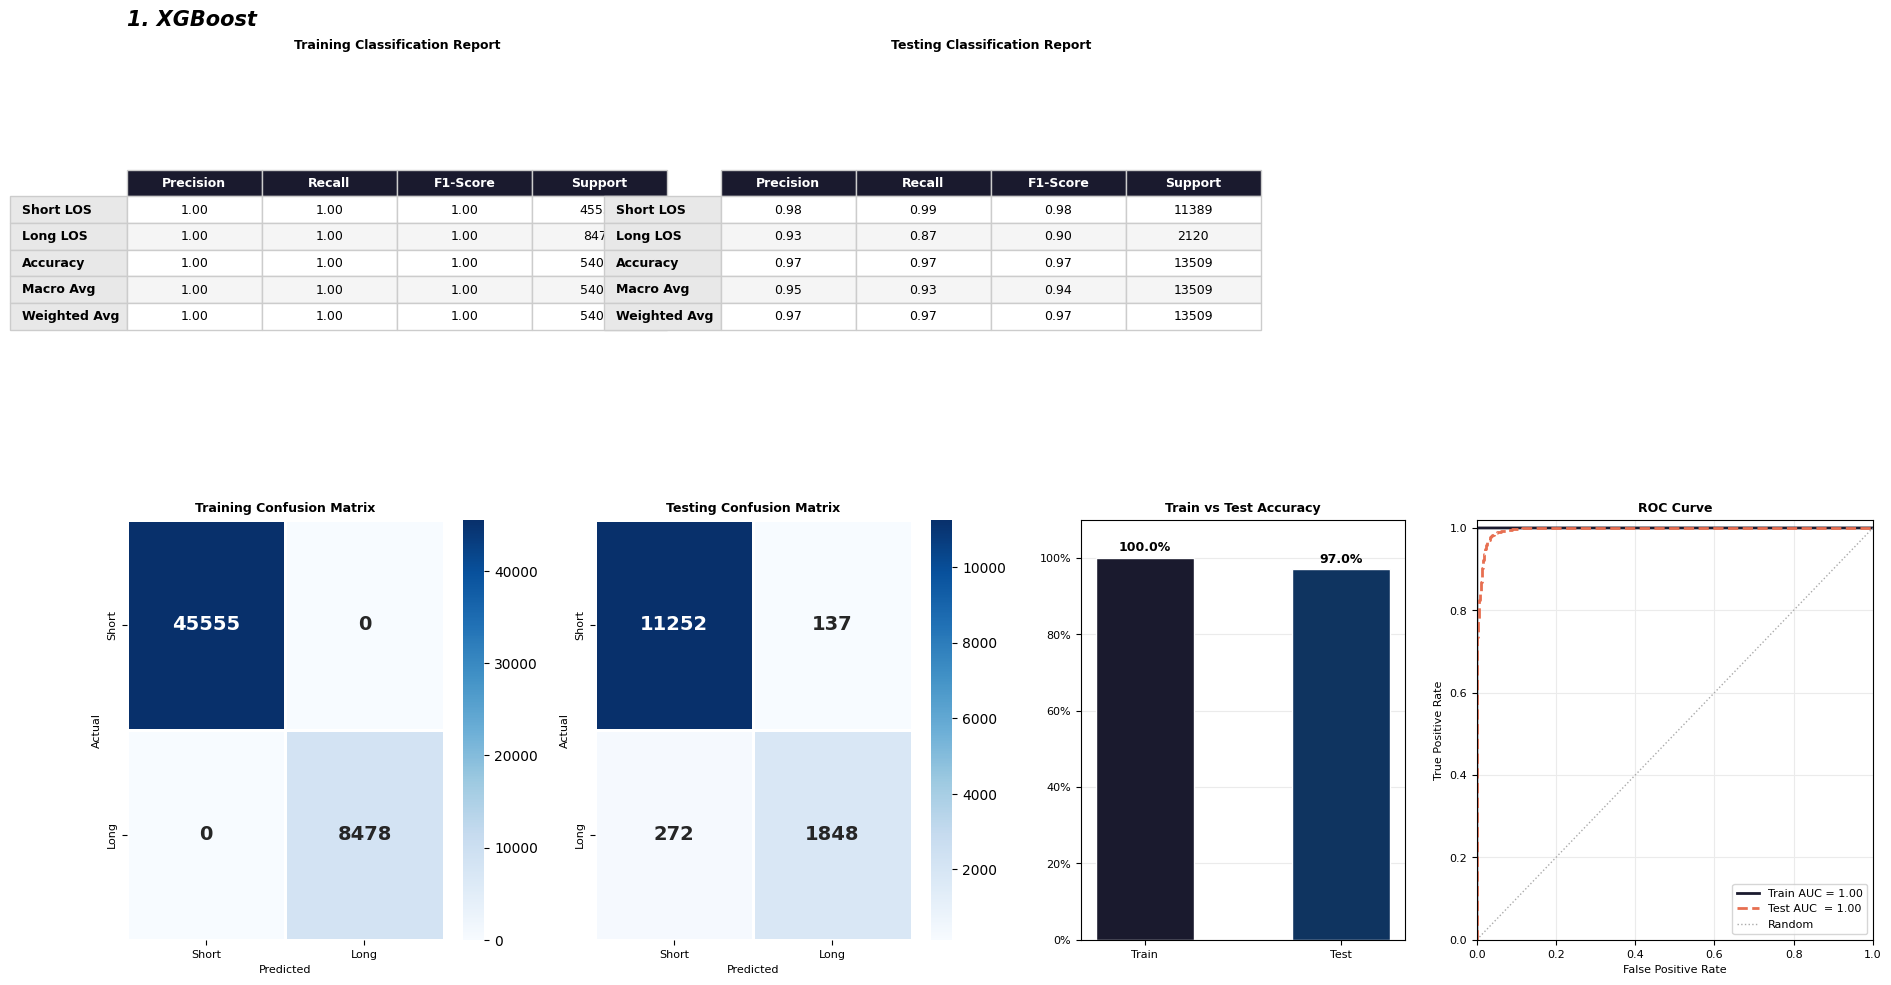

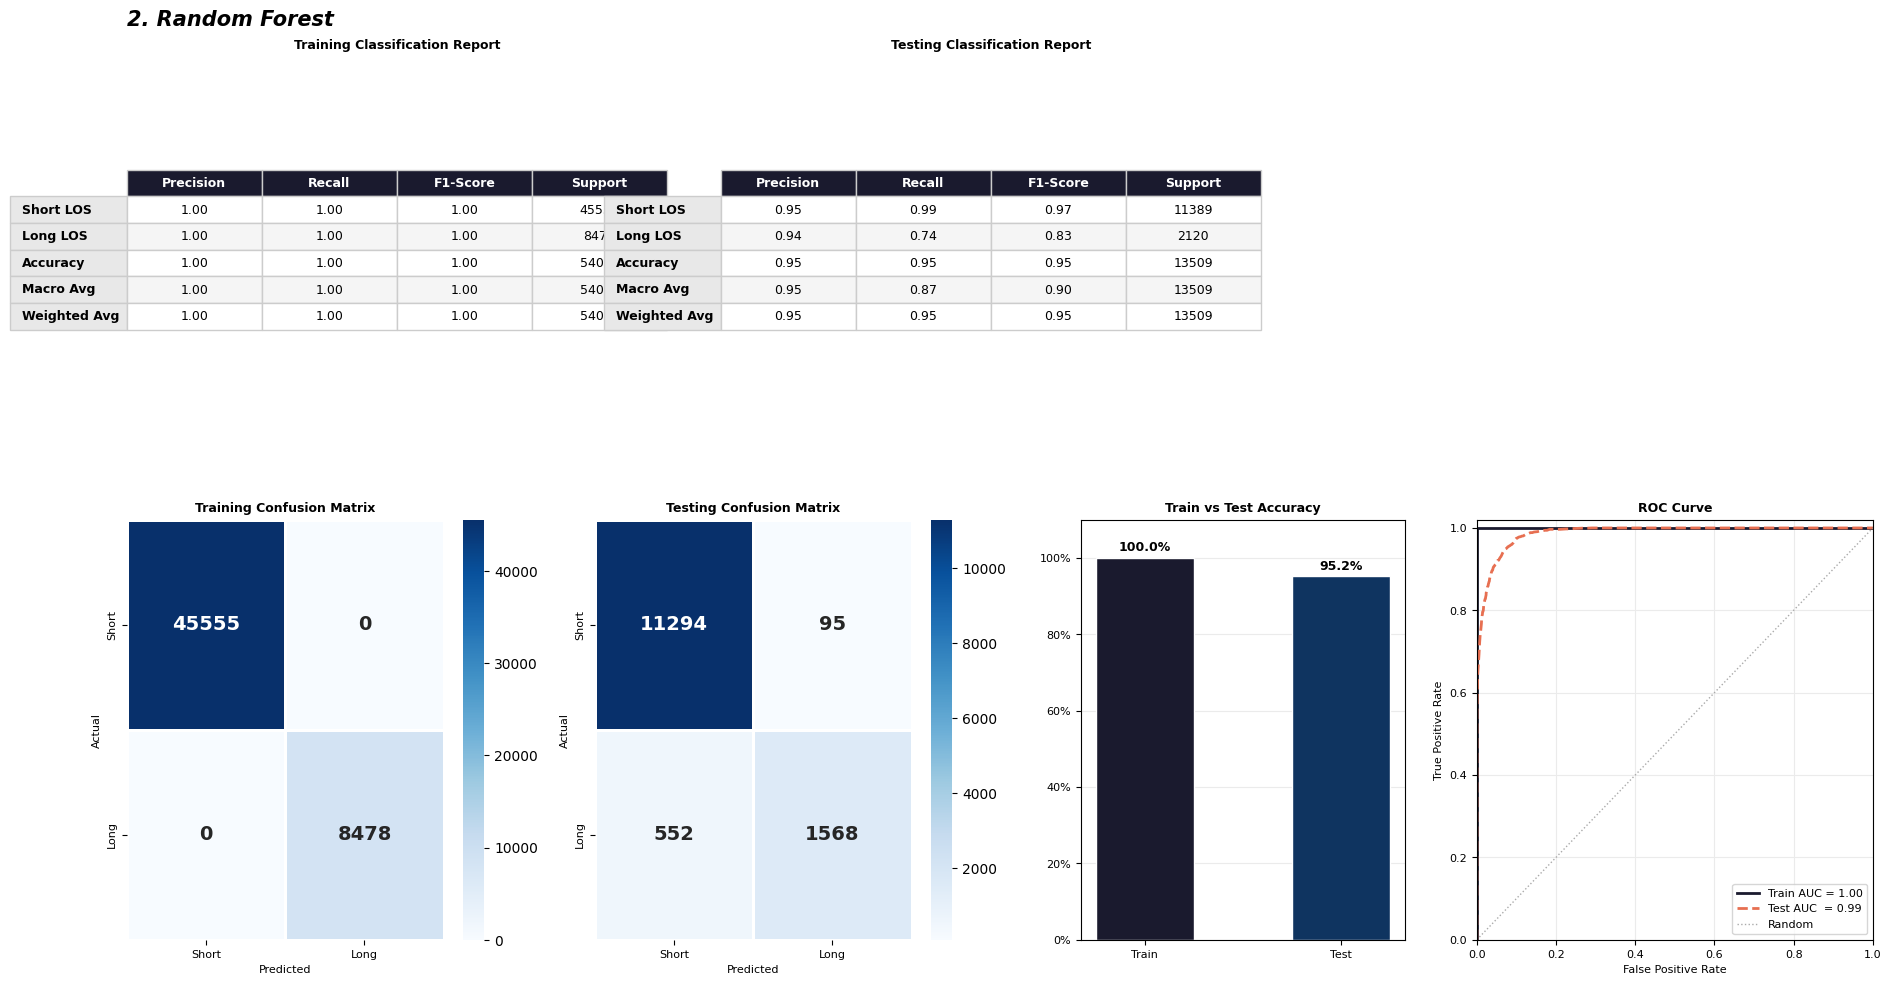

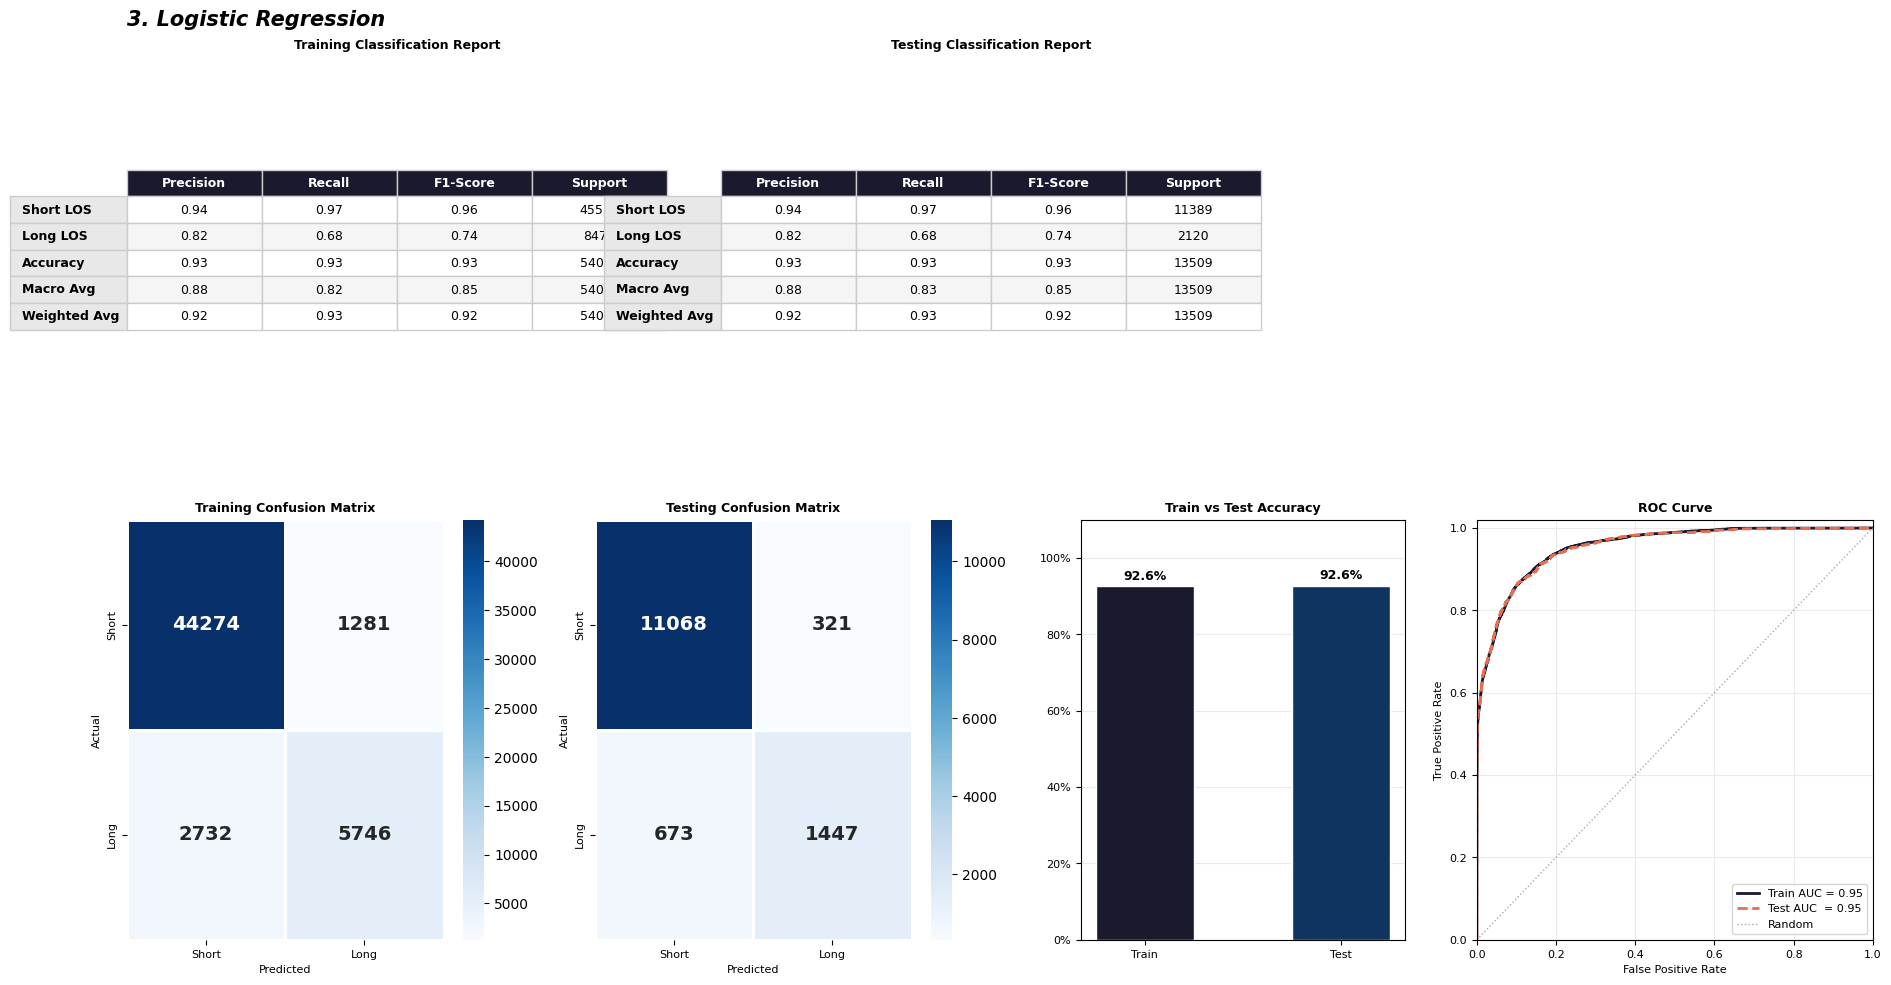

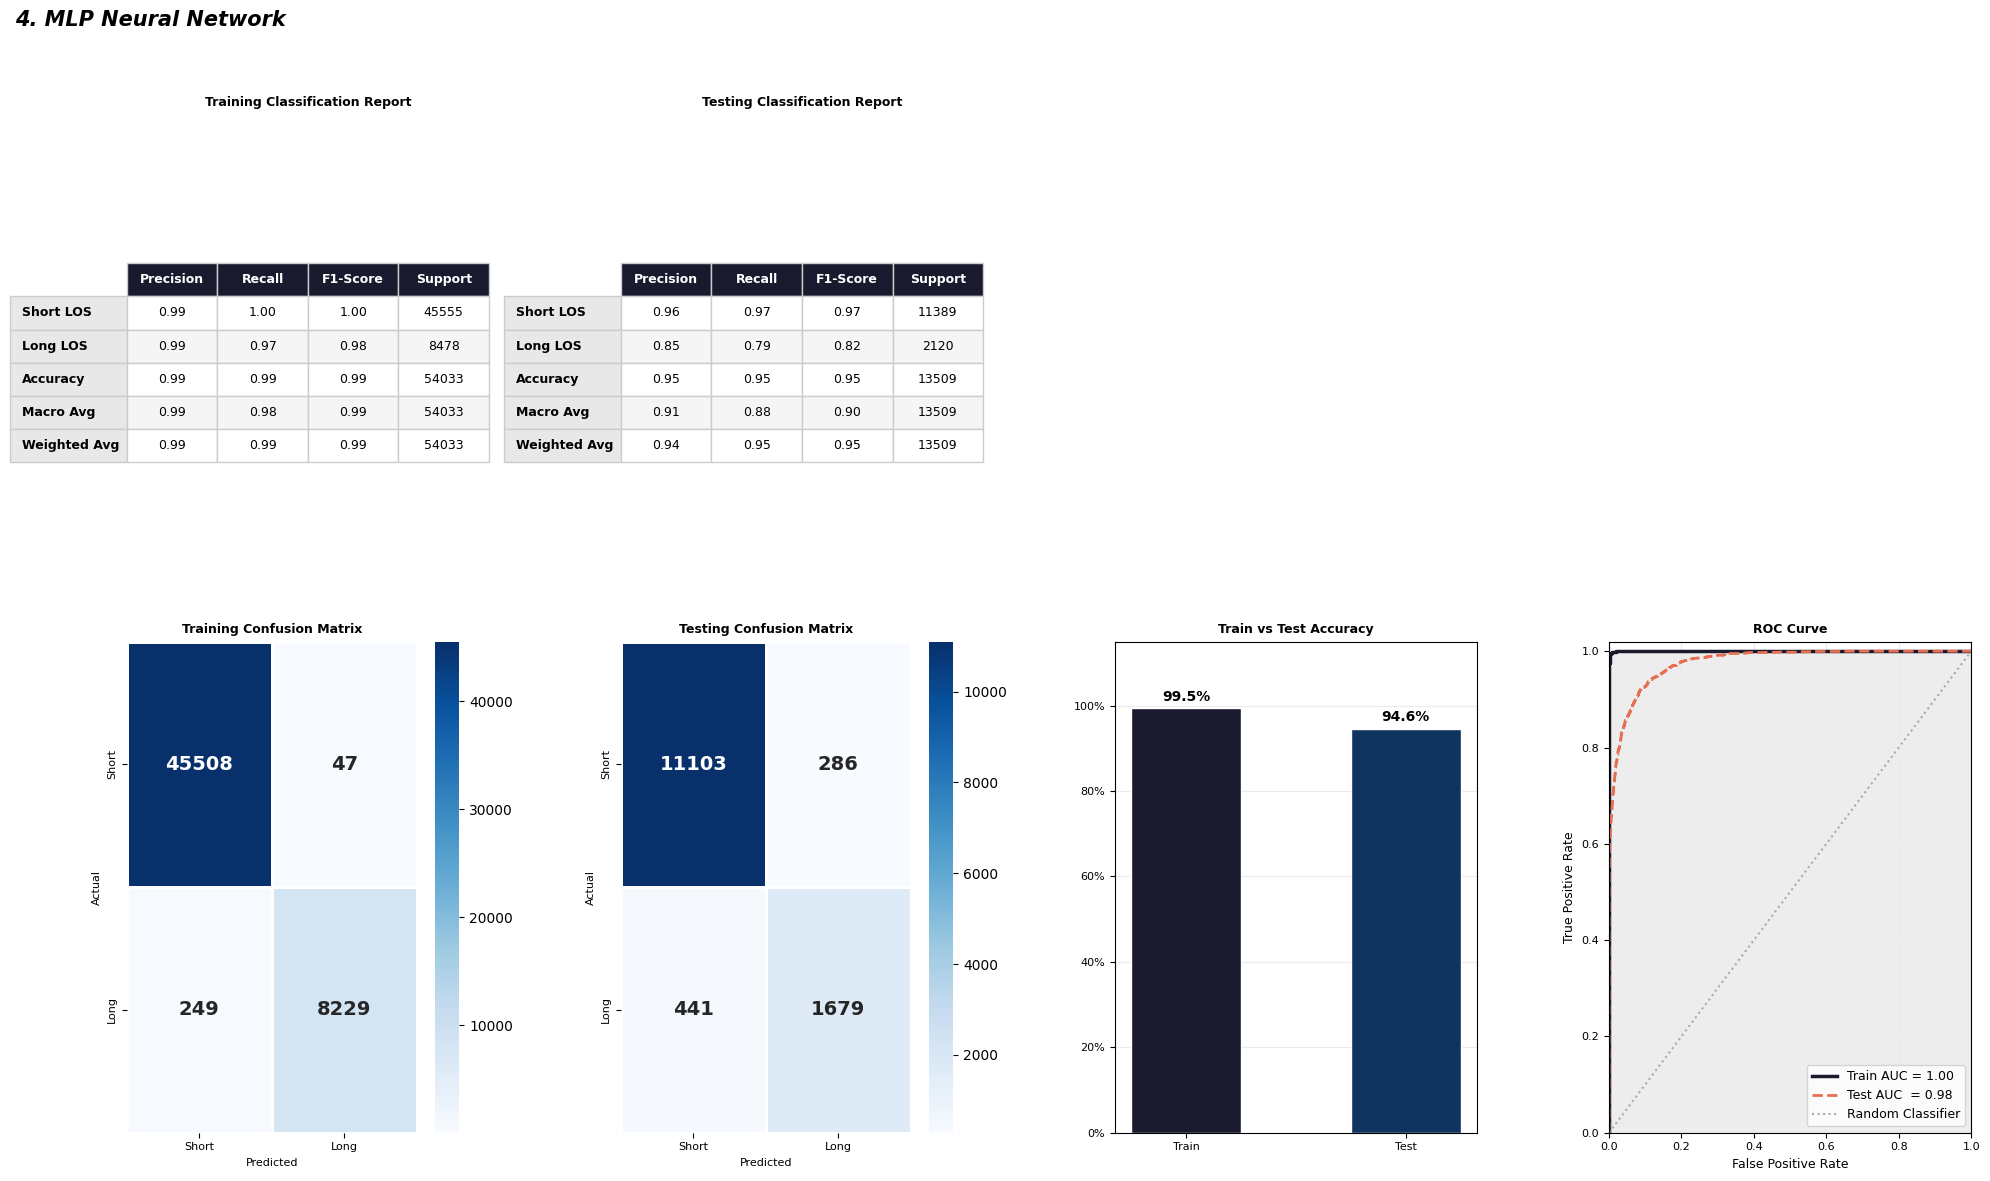


MODEL PERFORMANCE:

                     Accuracy  Precision  Recall  Specificity     F1  ROC_AUC  \
Logistic Regression     0.926      0.818   0.683        0.972  0.744    0.954   
Random Forest           0.952      0.943   0.740        0.992  0.829    0.987   
XGBoost                 0.970      0.931   0.872        0.988  0.900    0.996   
MLP                     0.946      0.854   0.792        0.975  0.822    0.977   

                     PR_AUC  LogLoss  
Logistic Regression   0.859    0.176  
Random Forest         0.945    0.121  
XGBoost               0.979    0.063  
MLP                   0.916    0.333  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    average_precision_score, log_loss, roc_curve,
    classification_report
)
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

plt.style.use("default")
sns.set_palette("husl")

df = pd.read_csv("/content/LengthOfStay.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

dataset_summary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.count().values,
    "Null Values": df.isnull().sum().values
})
print("\n========== DATASET SUMMARY ==========\n")
print(dataset_summary)

# --- FIX START: Add dropping NaN values ---
df.dropna(inplace=True)
print(f"\nDataset shape after dropping NaNs: {df.shape}")
# --- FIX END ---

df['label'] = (df['lengthofstay'] >= 7).astype(int)
df_processed = df.drop(columns=['vdate', 'discharged', 'lengthofstay'])
df_processed = pd.get_dummies(df_processed, columns=['rcount', 'gender', 'facid'], drop_first=True)

X = df_processed.drop('label', axis=1)
y = df_processed['label']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=500,
                               max_depth=7,
                               learning_rate=0.08,
                               eval_metric="logloss",
                               random_state=42
                           ),
    "MLP":                 MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

lr_model  = models["Logistic Regression"]
rf_model  = models["Random Forest"]
xgb_model = models["XGBoost"]
mlp_model = models["MLP"]

lr_model.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_scaled))
print("Logistic Regression Accuracy:", round(lr_acc * 100, 2), "%")

rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")

xgb_model.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test))
print("XGBoost Accuracy:", round(xgb_acc * 100, 2), "%")

mlp_model.fit(X_train_scaled, y_train)
mlp_acc = accuracy_score(y_test, mlp_model.predict(X_test_scaled))
print("MLP Accuracy:", round(mlp_acc * 100, 2), "%")

accuracies = {
    "Logistic Regression": lr_acc,
    "Random Forest":       rf_acc,
    "XGBoost":             xgb_acc,
    "MLP":                 mlp_acc
}

best_model_name = max(accuracies, key=accuracies.get)
best_model      = models[best_model_name]
print("\nBest Model:", best_model_name)
print("Best Accuracy:", round(accuracies[best_model_name] * 100, 2), "%")

X_test_df  = pd.DataFrame(X_test,  columns=X.columns)
X_train_df = pd.DataFrame(X_train, columns=X.columns)

plt.figure(figsize=(10, 6))
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    sorted_idx  = np.argsort(importances)
    plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])
elif hasattr(best_model, 'coef_'):
    importances = pd.Series(best_model.coef_[0], index=X.columns).abs().sort_values(ascending=False)
    plt.barh(importances.index, importances.values)
plt.xlabel("Feature Importance")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

probabilities = {}
for name, model in models.items():
    if name in ["Logistic Regression", "MLP"]:
        probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probabilities[name] = model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(7, 5))
for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score   = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

prob = (
    best_model.predict_proba(X_test_scaled)[:, 1]
    if best_model_name in ["Logistic Regression", "MLP"]
    else best_model.predict_proba(X_test)[:, 1]
)

gain_df            = pd.DataFrame({"actual": y_test, "prob": prob})
gain_df            = gain_df.sort_values("prob", ascending=False)
gain_df["cum_pos"] = gain_df["actual"].cumsum()
total_pos          = gain_df["actual"].sum()
gain_df["gain"]    = gain_df["cum_pos"] / total_pos
gain_df["percent"] = np.arange(1, len(gain_df) + 1) / len(gain_df)

plt.figure()
plt.plot(gain_df["percent"], gain_df["gain"], label="Model")
plt.plot([0, 1], [0, 1], label="Random")
plt.title("Cumulative Gain Curve")
plt.legend()
plt.show()

gain_df["lift"] = (
    gain_df["cum_pos"] / np.arange(1, len(gain_df) + 1)
) / (total_pos / len(gain_df))

plt.figure()
plt.plot(gain_df["percent"], gain_df["lift"], label="Model")
plt.plot([0, 1], [1, 1], label="Random")
plt.title("Lift Curve")
plt.xlabel("Percentage of Samples")
plt.ylabel("Lift")
plt.legend()
plt.show()

feature_to_plot_pdp = 'neutrophils'
if feature_to_plot_pdp not in feature_names:
    feature_to_plot_pdp = feature_names[0]

fig, ax = plt.subplots(figsize=(8, 6))
if best_model_name in ["Logistic Regression", "MLP"]:
    PartialDependenceDisplay.from_estimator(
        best_model,
        pd.DataFrame(X_train_scaled, columns=X.columns),
        [feature_to_plot_pdp], ax=ax
    )
else:
    PartialDependenceDisplay.from_estimator(
        best_model, X_train_df, [feature_to_plot_pdp], ax=ax
    )
plt.title("Partial Dependence Plot - " + feature_to_plot_pdp)
plt.tight_layout()
plt.show()

if best_model_name in ["XGBoost", "Random Forest"]:
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test_df, feature_names=feature_names, show=False)
    plt.title("SHAP Summary Plot (Global Feature Impact)")
    plt.tight_layout()
    plt.show()

    feature_to_plot_shap = 'neutrophils'
    if feature_to_plot_shap not in feature_names:
        feature_to_plot_shap = feature_names[0]

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        list(feature_names).index(feature_to_plot_shap),
        shap_values, X_test_df, feature_names=feature_names, show=False
    )
    plt.title(f"SHAP Dependence Plot - {feature_to_plot_shap}")
    plt.tight_layout()
    plt.show()

if best_model_name in ["MLP", "Logistic Regression"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

prob_cutoff = (
    best_model.predict_proba(X_test_scaled)[:, 1]
    if best_model_name in ["Logistic Regression", "MLP"]
    else best_model.predict_proba(X_test)[:, 1]
)
cutoff      = 0.5
pred_class  = (prob_cutoff >= cutoff).astype(int)
df_cut      = pd.DataFrame({"actual": y_test, "pred": pred_class})
below       = df_cut[df_cut["pred"] == 0]
above       = df_cut[df_cut["pred"] == 1]
short_below = sum(below["actual"] == 0)
long_below  = sum(below["actual"] == 1)
short_above = sum(above["actual"] == 0)
long_above  = sum(above["actual"] == 1)
labels      = ["Below cutoff", "Above cutoff"]
x           = np.arange(len(labels))

plt.figure()
plt.bar(x, [long_below, long_above],   label="Long LOS")
plt.bar(x, [short_below, short_above], bottom=[long_below, long_above], label="Short LOS")
plt.xticks(x, labels)
plt.title("Cutoff Distribution")
plt.legend()
plt.show()

def draw_report_table(ax, report_dict, title):
    ax.axis('off')
    rows       = ["Short LOS", "Long LOS", "accuracy", "macro avg", "weighted avg"]
    row_labels = ["Short LOS", "Long LOS", "Accuracy", "Macro Avg", "Weighted Avg"]
    table_data = []
    for r in rows:
        if r == "accuracy":
            acc_val = report_dict['accuracy']
            sup_val = report_dict['weighted avg']['support']
            table_data.append([f"{acc_val:.2f}", f"{acc_val:.2f}", f"{acc_val:.2f}", f"{sup_val:.0f}"])
        else:
            rd = report_dict.get(r, {})
            table_data.append([
                f"{rd.get('precision', 0):.2f}",
                f"{rd.get('recall',    0):.2f}",
                f"{rd.get('f1-score',  0):.2f}",
                f"{rd.get('support',   0):.0f}"
            ])
    tbl = ax.table(
        cellText=table_data, rowLabels=row_labels,
        colLabels=["Precision", "Recall", "F1-Score", "Support"],
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#1a1a2e')
            cell.set_text_props(color='white', fontweight='bold')
        elif col == -1:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#f5f5f5')
        cell.set_edgecolor('#cccccc')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=8)

model_list = [
    ("1. XGBoost",             xgb_model, X_train,        X_test,        y_train, y_test),
    ("2. Random Forest",       rf_model,  X_train,        X_test,        y_train, y_test),
    ("3. Logistic Regression", lr_model,  X_train_scaled, X_test_scaled, y_train, y_test),
]

for (model_name, model, Xtr, Xte, ytr, yte) in model_list:
    y_pred_train = model.predict(Xtr)
    y_pred_test  = model.predict(Xte)
    train_acc    = accuracy_score(ytr, y_pred_train)
    test_acc     = accuracy_score(yte, y_pred_test)
    cm_train     = confusion_matrix(ytr, y_pred_train)
    cm_test      = confusion_matrix(yte, y_pred_test)
    train_report = classification_report(ytr, y_pred_train, target_names=["Short LOS", "Long LOS"], output_dict=True)
    test_report  = classification_report(yte, y_pred_test,  target_names=["Short LOS", "Long LOS"], output_dict=True)

    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(model_name, fontsize=15, fontweight='bold', fontstyle='italic', x=0.01, ha='left')

    ax_tr = fig.add_axes([0.01, 0.55, 0.30, 0.38])
    ax_te = fig.add_axes([0.34, 0.55, 0.30, 0.38])
    draw_report_table(ax_tr, train_report, "Training Classification Report")
    draw_report_table(ax_te, test_report,  "Testing Classification Report")

    ax_tcm = fig.add_axes([0.01, 0.05, 0.22, 0.42])
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Short", "Long"], yticklabels=["Short", "Long"],
                linewidths=2, linecolor='white', annot_kws={"size": 14, "weight": "bold"}, ax=ax_tcm)
    ax_tcm.set_title("Training Confusion Matrix", fontsize=9, fontweight='bold')
    ax_tcm.set_xlabel("Predicted", fontsize=8)
    ax_tcm.set_ylabel("Actual", fontsize=8)
    ax_tcm.tick_params(labelsize=8)

    ax_ecm = fig.add_axes([0.27, 0.05, 0.22, 0.42])
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Short", "Long"], yticklabels=["Short", "Long"],
                linewidths=2, linecolor='white', annot_kws={"size": 14, "weight": "bold"}, ax=ax_ecm)
    ax_ecm.set_title("Testing Confusion Matrix", fontsize=9, fontweight='bold')
    ax_ecm.set_xlabel("Predicted", fontsize=8)
    ax_ecm.set_ylabel("Actual", fontsize=8)
    ax_ecm.tick_params(labelsize=8)

    ax_acc = fig.add_axes([0.54, 0.05, 0.18, 0.42])
    bars = ax_acc.bar(["Train", "Test"], [train_acc, test_acc],
                      color=["#1a1a2e", "#0f3460"], width=0.5, edgecolor='white')
    for bar, val in zip(bars, [train_acc, test_acc]):
        ax_acc.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val * 100:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_acc.set_ylim(0, 1.1)
    ax_acc.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax_acc.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"], fontsize=8)
    ax_acc.set_title("Train vs Test Accuracy", fontsize=9, fontweight='bold')
    ax_acc.tick_params(labelsize=8)
    ax_acc.grid(axis='y', color='#ebebeb')
    ax_acc.set_axisbelow(True)

    ax_roc = fig.add_axes([0.76, 0.05, 0.22, 0.42])
    train_prob         = model.predict_proba(Xtr)[:, 1]
    test_prob          = model.predict_proba(Xte)[:, 1]
    fpr_tr, tpr_tr, _ = roc_curve(ytr, train_prob)
    fpr_te, tpr_te, _ = roc_curve(yte, test_prob)
    auc_tr             = roc_auc_score(ytr, train_prob)
    auc_te             = roc_auc_score(yte, test_prob)
    ax_roc.plot(fpr_tr, tpr_tr, color='#1a1a2e', lw=2, label=f"Train AUC = {auc_tr:.2f}")
    ax_roc.plot(fpr_te, tpr_te, color='#e76f51', lw=2, linestyle='--', label=f"Test AUC  = {auc_te:.2f}")
    ax_roc.plot([0, 1], [0, 1], color='#aaaaaa', lw=1, linestyle=':', label="Random")
    ax_roc.set_xlim(0, 1)
    ax_roc.set_ylim(0, 1.02)
    ax_roc.set_xlabel("False Positive Rate", fontsize=8)
    ax_roc.set_ylabel("True Positive Rate", fontsize=8)
    ax_roc.set_title("ROC Curve", fontsize=9, fontweight='bold')
    ax_roc.legend(fontsize=8, loc='lower right')
    ax_roc.tick_params(labelsize=8)
    ax_roc.grid(color='#ebebeb')

    plt.show()

Xtr_mlp = X_train_scaled
Xte_mlp = X_test_scaled
ytr_mlp = y_train
yte_mlp = y_test

y_pred_train_mlp = mlp_model.predict(Xtr_mlp)
y_pred_test_mlp  = mlp_model.predict(Xte_mlp)
train_acc_mlp    = accuracy_score(ytr_mlp, y_pred_train_mlp)
test_acc_mlp     = accuracy_score(yte_mlp, y_pred_test_mlp)
cm_train_mlp     = confusion_matrix(ytr_mlp, y_pred_train_mlp)
cm_test_mlp      = confusion_matrix(yte_mlp, y_pred_test_mlp)
train_prob_mlp   = mlp_model.predict_proba(Xtr_mlp)[:, 1]
test_prob_mlp    = mlp_model.predict_proba(Xte_mlp)[:, 1]

fpr_tr_mlp, tpr_tr_mlp, _ = roc_curve(ytr_mlp, train_prob_mlp)
fpr_te_mlp, tpr_te_mlp, _ = roc_curve(yte_mlp, test_prob_mlp)
auc_tr_mlp = roc_auc_score(ytr_mlp, train_prob_mlp)
auc_te_mlp = roc_auc_score(yte_mlp, test_prob_mlp)

train_report_mlp = classification_report(ytr_mlp, y_pred_train_mlp, target_names=["Short LOS", "Long LOS"], output_dict=True)
test_report_mlp  = classification_report(yte_mlp, y_pred_test_mlp,  target_names=["Short LOS", "Long LOS"], output_dict=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle("4. MLP Neural Network", fontsize=15, fontweight='bold', fontstyle='italic', x=0.01, ha='left')

rows_label = ["Short LOS", "Long LOS", "Accuracy", "Macro Avg", "Weighted Avg"]
rows_key   = ["Short LOS", "Long LOS", "accuracy", "macro avg", "weighted avg"]

for ax_idx, (report, title) in enumerate([(train_report_mlp, "Training Classification Report"),
                                           (test_report_mlp,  "Testing Classification Report")]):
    ax = axes[0, ax_idx]
    ax.axis('off')
    table_data = []
    for r in rows_key:
        if r == "accuracy":
            v = report['accuracy']
            s = report['weighted avg']['support']
            table_data.append([f"{v:.2f}", f"{v:.2f}", f"{v:.2f}", f"{s:.0f}"])
        else:
            rd = report.get(r, {})
            table_data.append([f"{rd.get('precision',0):.2f}", f"{rd.get('recall',0):.2f}",
                                f"{rd.get('f1-score',0):.2f}", f"{rd.get('support',0):.0f}"])
    tbl = ax.table(cellText=table_data, rowLabels=rows_label,
                   colLabels=["Precision","Recall","F1-Score","Support"],
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.7)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#1a1a2e')
            cell.set_text_props(color='white', fontweight='bold')
        elif col == -1:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#f5f5f5')
        cell.set_edgecolor('#cccccc')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=8)

axes[0, 2].axis('off')
axes[0, 3].axis('off')

for ax, cm, title in [(axes[1,0], cm_train_mlp, "Training Confusion Matrix"),
                       (axes[1,1], cm_test_mlp,  "Testing Confusion Matrix")]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Short","Long"], yticklabels=["Short","Long"],
                linewidths=2, linecolor='white',
                annot_kws={"size":14,"weight":"bold"}, ax=ax)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(labelsize=8)

ax = axes[1, 2]
bars = ax.bar(["Train","Test"], [train_acc_mlp, test_acc_mlp],
              color=["#1a1a2e","#0f3460"], width=0.5, edgecolor='white')
for bar, val in zip(bars, [train_acc_mlp, test_acc_mlp]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val*100:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0%","20%","40%","60%","80%","100%"], fontsize=8)
ax.set_title("Train vs Test Accuracy", fontsize=9, fontweight='bold')
ax.tick_params(labelsize=8)
ax.grid(axis='y', color='#ebebeb')
ax.set_axisbelow(True)

ax = axes[1, 3]
ax.fill_between(fpr_tr_mlp, tpr_tr_mlp, alpha=0.08, color='#1a1a2e')
ax.plot(fpr_tr_mlp, tpr_tr_mlp, color='#1a1a2e', lw=2.5,
        label=f"Train AUC = {auc_tr_mlp:.2f}")
ax.plot(fpr_te_mlp, tpr_te_mlp, color='#e76f51', lw=2, linestyle='--',
        label=f"Test AUC  = {auc_te_mlp:.2f}")
ax.plot([0,1],[0,1], color='#aaaaaa', lw=1.5, linestyle=':',
        label="Random Classifier")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate", fontsize=9)
ax.set_ylabel("True Positive Rate", fontsize=9)
ax.set_title("ROC Curve", fontsize=9, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.tick_params(labelsize=8)
ax.grid(color='#ebebeb')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

results = {}
for name, model in models.items():
    if name in ["Logistic Regression", "MLP"]:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    results[name] = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred),
        tn / (tn + fp),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob),
        log_loss(y_test, y_prob)
    ]

columns = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "ROC_AUC", "PR_AUC", "LogLoss"]
performance_df = pd.DataFrame(results, index=columns).T
print("\nMODEL PERFORMANCE:\n")
print(performance_df.round(3))
